# F_ephys_behavior_examples.ipynb

## Purpose

Generates single-unit example raster + PSTH figures for a curated set of representative neurons (13 examples from both silicon probe and tetrode recordings), plotted for stay-vs-switch and hit-vs-miss behavioral splits.

## Manuscript figure panels

- Fig6 d

## Prerequisites

Before running this notebook, ensure the figure preparation scripts have been run in sequence (see `/root/capsule/code/beh_ephys_analysis/session_combine/figure_preparation/sequence`).

Required input files:
- `combined_unit_tbl.pkl` (Step 1)
- Per-session spike data

## Setup and Imports

Import required libraries for data processing, spike analysis, and visualization. This notebook uses custom utilities from the capsule for loading behavioral and electrophysiology data, as well as standard scientific Python packages for statistical analysis and plotting.

In [44]:
import sys
import os
from matplotlib.colors import LinearSegmentedColormap
# Resolve code/beh_ephys_analysis (the folder containing `utils`) relative to this
# file's location, so imports work no matter where the repo is checked out.
import pathlib

# Resolve code/beh_ephys_analysis (the folder containing `utils`) relative to this
# file's location, so imports work no matter where the repo is checked out.
try:
    _here = pathlib.Path(__file__).resolve().parent          # script mode
except NameError:
    try:
        _here = pathlib.Path(__vsc_ipynb_file__).resolve().parent  # VS Code notebook
    except NameError:
        _here = pathlib.Path(os.getcwd())                    # other Jupyter fallback

_beh_ephys_root = str((_here / '../..').resolve())
if _beh_ephys_root not in sys.path:
    sys.path.insert(0, _beh_ephys_root)
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd
from pynwb import NWBFile, TimeSeries, NWBHDF5IO
from scipy.io import loadmat
from scipy.stats import zscore
import ast
from pathlib import Path
import glob
import json
import seaborn as sns
from PyPDF2 import PdfMerger
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm
import re
from utils.beh_functions import session_dirs, parseSessionID, load_model_dv, makeSessionDF, get_session_tbl, get_unit_tbl, get_history_from_nwb
from utils.ephys_functions import*
from utils.ccf_utils import ccf_pts_convert_to_mm, pir_to_lps, project_to_plane
from utils.combine_tools import apply_qc, to_str_intlike
from utils.capsule_migration import capsule_directories
from utils.panel_utils import save_panels, save_panel_csv, columns_to_df, heatmap_to_df
from ani_session_processing.antidromic_analysis_session import plot_opto_responses
import pickle
import scipy.stats as stats
import spikeinterface as si
import shutil
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.metrics import r2_score
import warnings
from scipy.stats import gaussian_kde
import trimesh
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.cm as cm
from utils.ccf_utils import ccf_pts_convert_to_mm
from trimesh import load_mesh
from scipy.stats import pearsonr
import statsmodels.api as sm
from aind_ephys_utils import align
import k3d
warnings.filterwarnings('ignore')
capsule_dirs = capsule_directories()

%matplotlib inline

## Configure Output Directory

Set up the target folder for saving example neuron figures. All raster plots and PSTH figures will be saved as both PDF and SVG formats in this directory.

In [45]:
target_folder = f'{capsule_dirs["manuscript_fig_dir"]}/F_ephys_beh_action&outcome/example_figs'
if not os.path.exists(target_folder):
    os.makedirs(target_folder)

# Stay vs Swtich example


### Define Stay vs Switch Example Neurons

This list contains 13 curated example neurons (session ID, unit ID pairs) that show clear differential responses between stay and switch trials. The examples include neurons from both silicon probe recordings (numeric unit IDs) and tetrode recordings (string unit IDs like 'TT3_SS_01').

In [46]:
examples = [('behavior_751004_2024-12-21_13-28-28', 22), 
            ('behavior_751766_2025-02-11_11-53-38', 285),
            ('behavior_751766_2025-02-13_11-31-21', 144),
            ('behavior_754897_2025-03-13_11-20-42', 54),
            ('behavior_758017_2025-02-04_11-57-38', 5),
            ('behavior_758017_2025-02-07_14-11-08', 17),
            ('behavior_761038_2025-04-18_12-37-39', 12)]

### Create Custom Colormap

Define a custom colormap for stay vs switch visualization, transitioning from green (stay trials) through white to purple (switch trials). This colormap will be used in the raster plots to distinguish between trial types.

In [47]:
custom_cmap = LinearSegmentedColormap.from_list('switch', [(0.0, 'green'), (0.5, 'white'), (1.0, 'purple')])

### Generate Stay vs Switch Raster Plots

For each example neuron, create a combined raster plot and peri-stimulus time histogram (PSTH) showing neural activity aligned to the go cue. Trials are separated by whether the animal stayed at the same port or switched to a different port. The code handles data quality by applying drift cuts when available, removing epochs with unstable recordings. Output figures show firing patterns from -1s to +2s relative to the go cue.

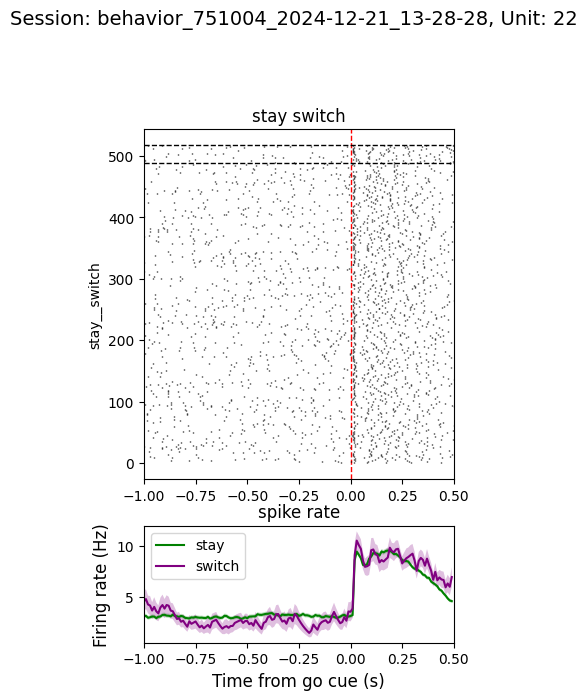

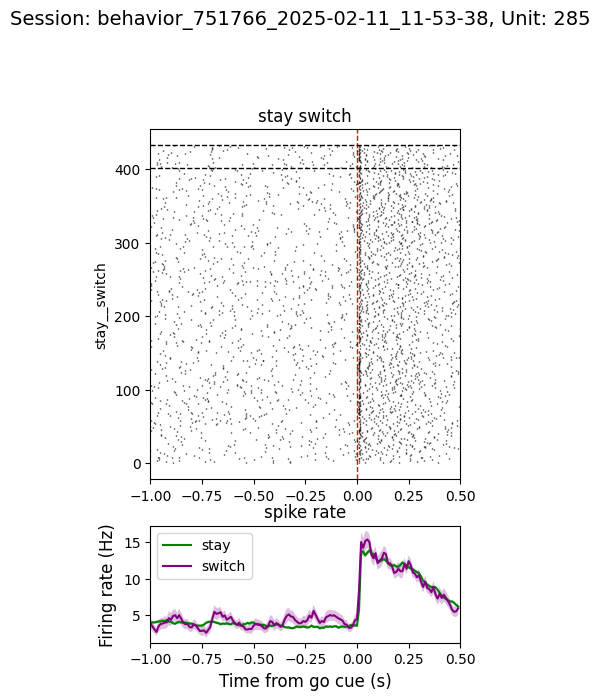

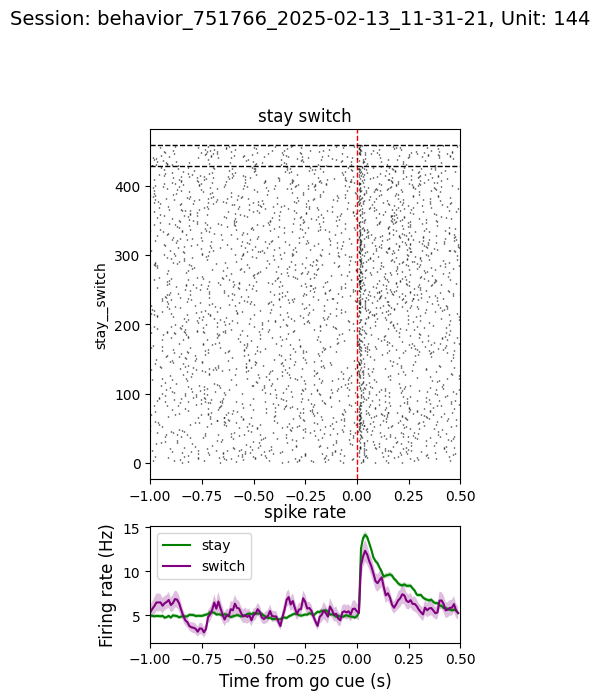

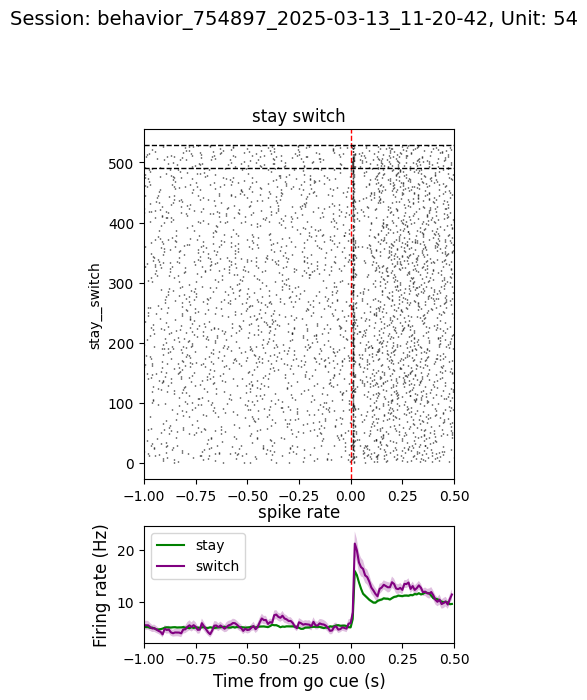

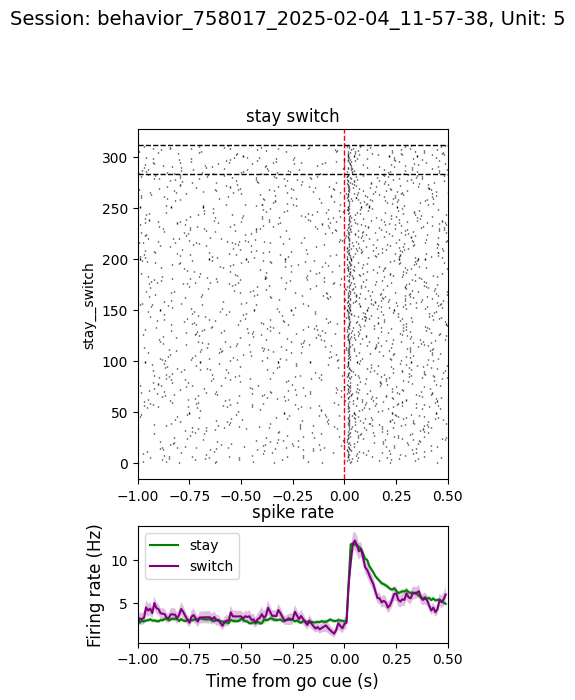

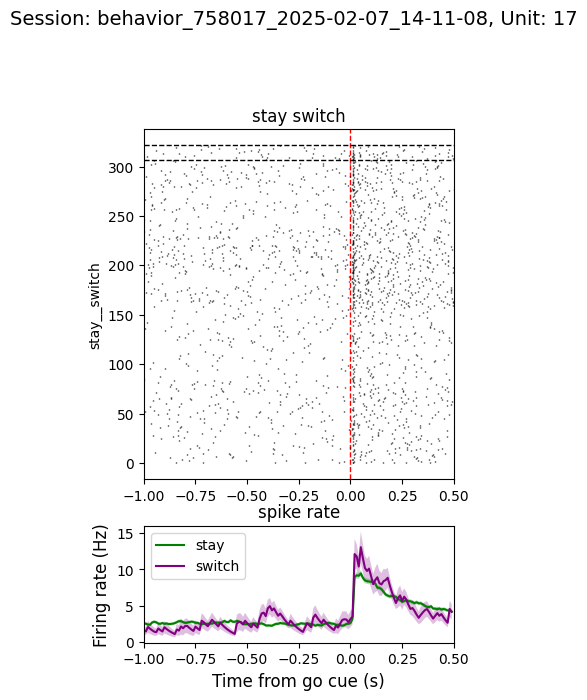

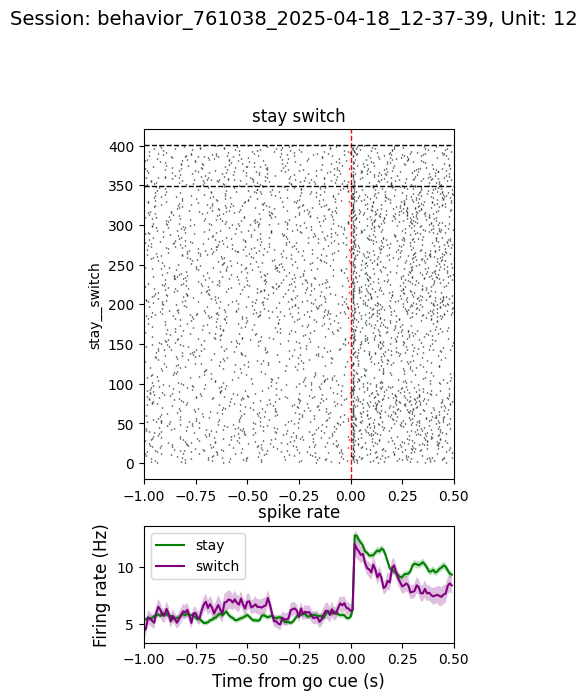

In [48]:
for curr_ind, curr_example in enumerate(examples):
    session = curr_example[0]
    unit_id = curr_example[1]
    session_df = get_session_tbl(session)
    session_tbl = makeSessionDF(session)
    unit_tbl = get_unit_tbl(session, data_type='curated')
    spike_times = unit_tbl.loc[unit_tbl['unit_id'] == unit_id, 'spike_times'].values[0] 
    unit_drift = load_drift(session, unit_id, data_type='curated')
    session_df_curr = session_tbl.copy()
    spike_times_curr = spike_times.copy()
    if unit_drift is not None:
        if unit_drift['ephys_cut'][0] is not None:
            spike_times_curr = spike_times_curr[spike_times_curr >= unit_drift['ephys_cut'][0]]
            session_df_curr = session_df_curr[session_df_curr['go_cue_time'] >= unit_drift['ephys_cut'][0]]
        if unit_drift['ephys_cut'][1] is not None:
            spike_times_curr = spike_times_curr[spike_times_curr <= unit_drift['ephys_cut'][1]]
            session_df_curr = session_df_curr[session_df_curr['go_cue_time'] <= unit_drift['ephys_cut'][1]]
    fig = plt.figure(figsize=(4,12))
    gs = gridspec.GridSpec(2, 1, height_ratios=[2, 1], hspace=0.4)
    fig, ax1, ax2 = plot_raster_rate(spike_times_curr,session_df_curr['go_cue_time'].values, 
                                session_df_curr['svs'], [-1, 0.5, 2], ['stay', 'switch'], 
                                custom_cmap, fig, gs[0], kernel = True, tb=-1, tf=0.5, tau_decay=0.08, tau_rise=0.001, step_size= 0.01)
    ax2.set_ylabel('Firing rate (Hz)', fontsize=12)
    ax2.set_xlabel('Time from go cue (s)', fontsize=12)
    plt.suptitle(f'Session: {session}, Unit: {unit_id}', fontsize=14)
    plt.tight_layout()
    plt.savefig(os.path.join(target_folder, f'switch-stay_{session}_{unit_id}.pdf'))
    plt.savefig(os.path.join(target_folder, f'switch-stay_{session}_{unit_id}.svg'))

# Miss vs Hit

### Define Hit vs Miss Example Neurons

This list contains 11 curated example neurons that show differential activity between hit and miss trials. These neurons exhibit clear modulation based on trial outcome, helping to understand the neural correlates of successful vs unsuccessful behavioral performance.

In [49]:
examples = [('behavior_754897_2025-03-13_11-20-42', 26), 
            ('behavior_752014_2025-03-28_11-04-59', 27),
            ('behavior_751766_2025-02-14_11-37-11', 36),
            ('behavior_716325_2024-05-31_10-31-14', 87),
            ('behavior_ZS061_2021-04-30_17-06-18','TT4_SS_01'),
            ('behavior_ZS062_2021-03-27_19-15-29','TT4_SS_01'),
            ('behavior_ZS062_2021-04-02_19-08-52','TT7_SS_01'),
            ('behavior_ZS061_2021-03-29_17-48-18','TT5_SS_01'),
            ('behavior_ZS061_2021-03-29_17-48-18','TT4_SS_01'),
            ('behavior_ZS061_2021-03-22_17-35-53','TT4_SS_01'),
            ('behavior_ZS061_2021-03-23_16-08-12','TT4_SS_01')]

### Create Hit vs Miss Colormap

Define a custom colormap for hit vs miss visualization, transitioning from blue (miss trials) through white to orange (hit trials). This colormap distinguishes between successful and unsuccessful behavioral outcomes in the raster plots.

In [50]:
custom_cmap = LinearSegmentedColormap.from_list('hit', [(0.0, 'blue'), (0.5, 'white'), (1.0, 'orange')])

### Generate Hit vs Miss Raster Plots

Generate raster plots and PSTHs for hit vs miss trial comparisons. Each neuron's activity is aligned to the go cue, with trials categorized by behavioral outcome (hit = correct response, miss = incorrect response). The analysis applies the same drift correction and time window (-1s to +2s) as the stay/switch analysis, ensuring consistent data quality across all example figures.

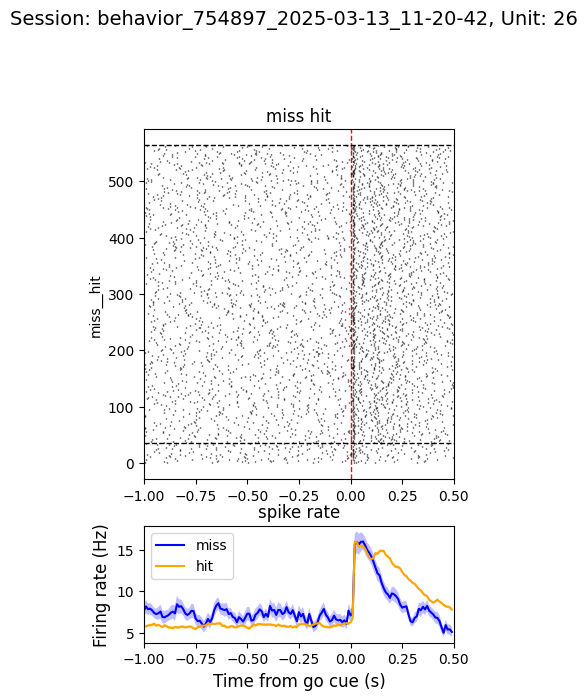

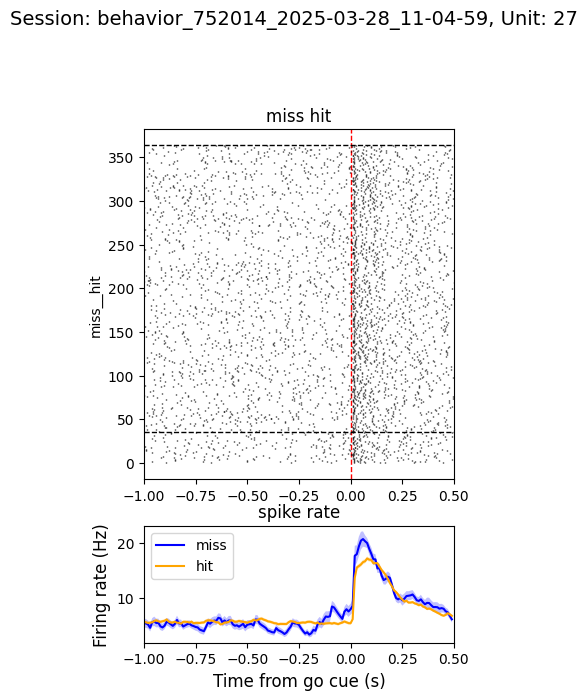

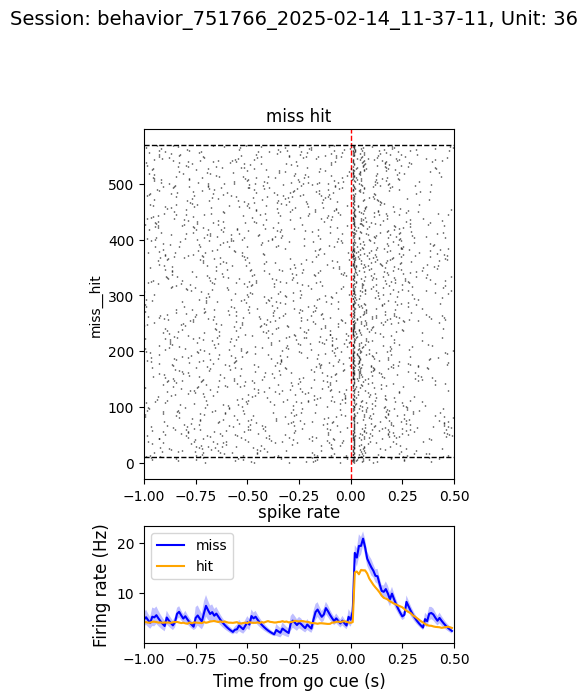

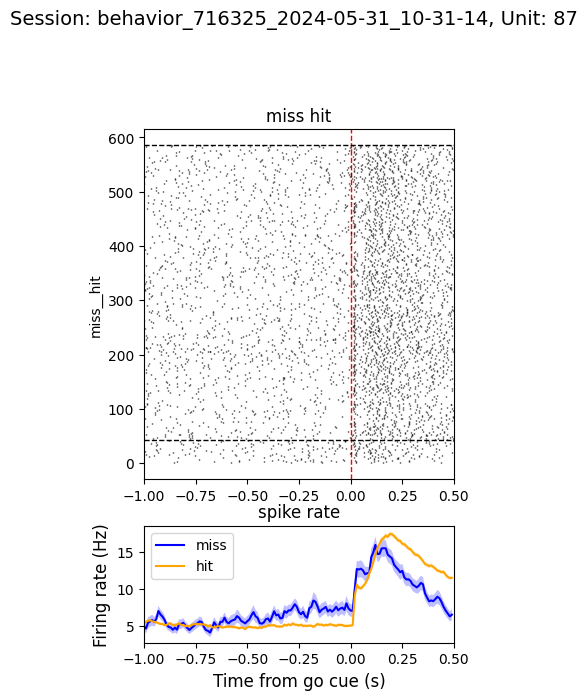

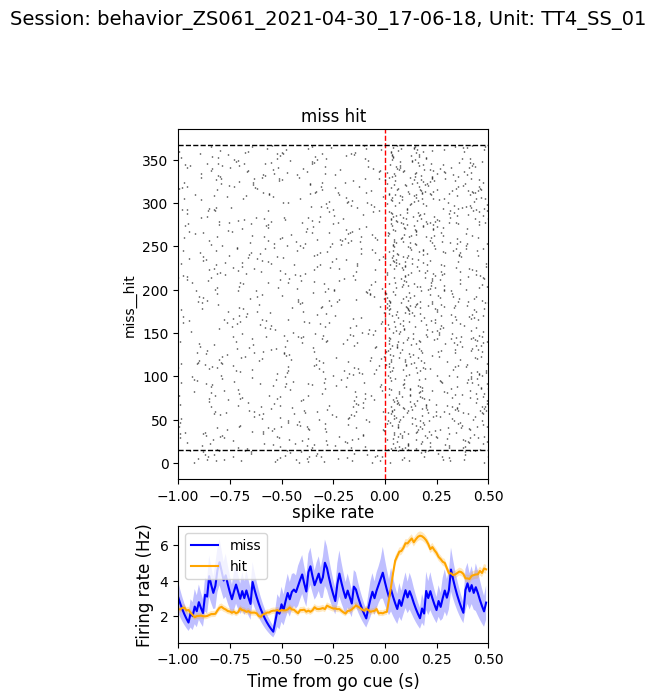

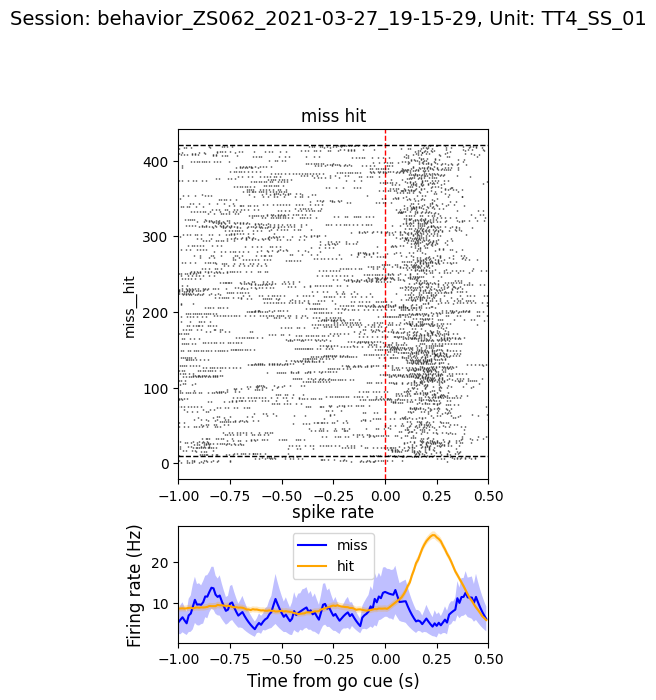

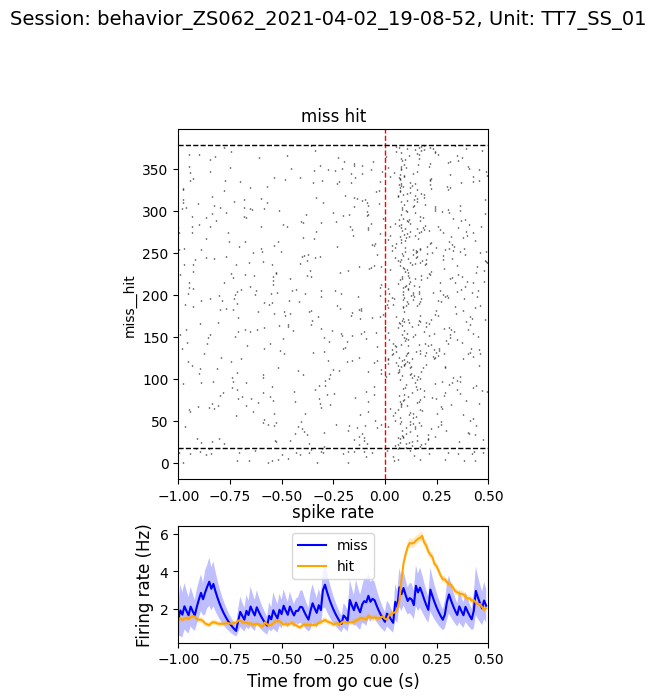

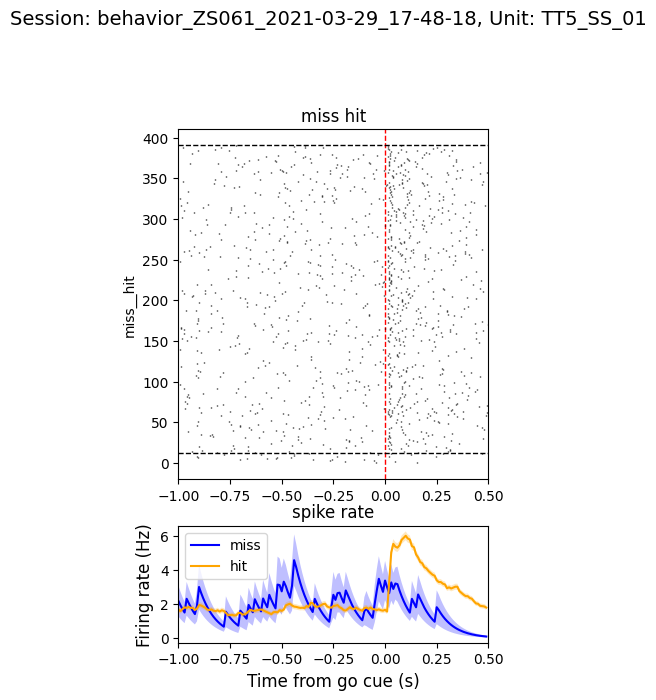

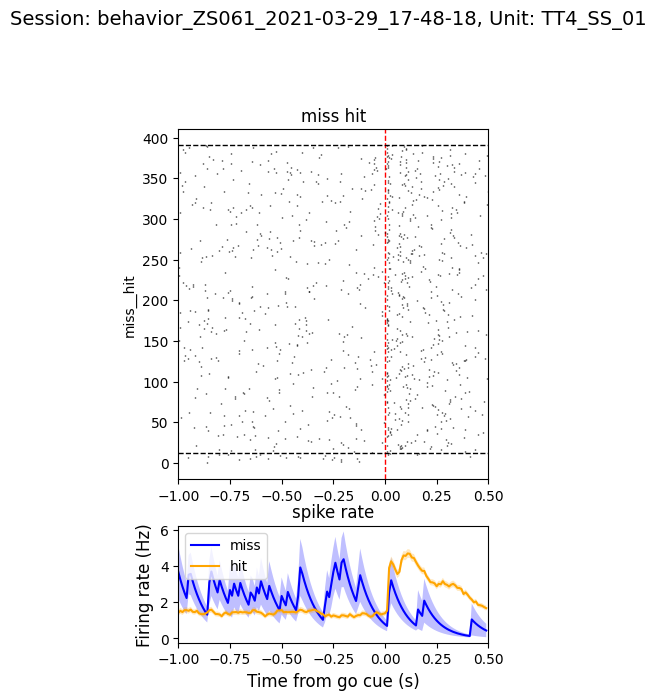

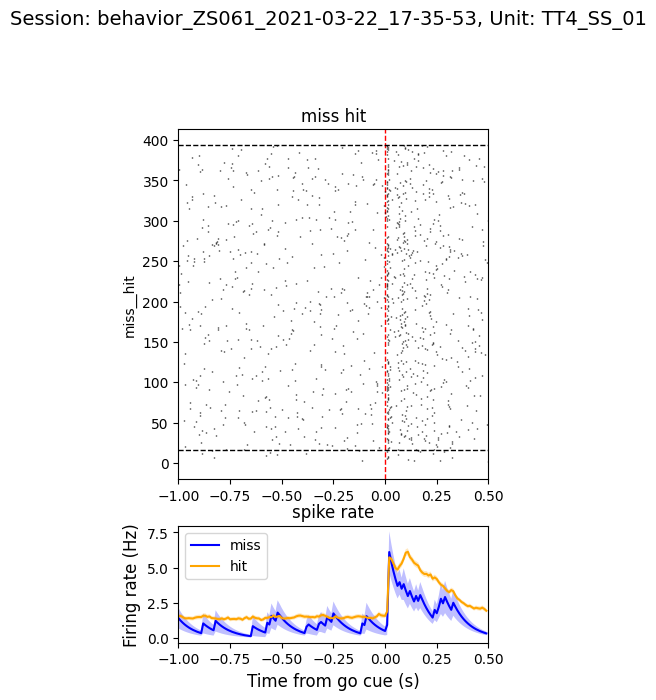

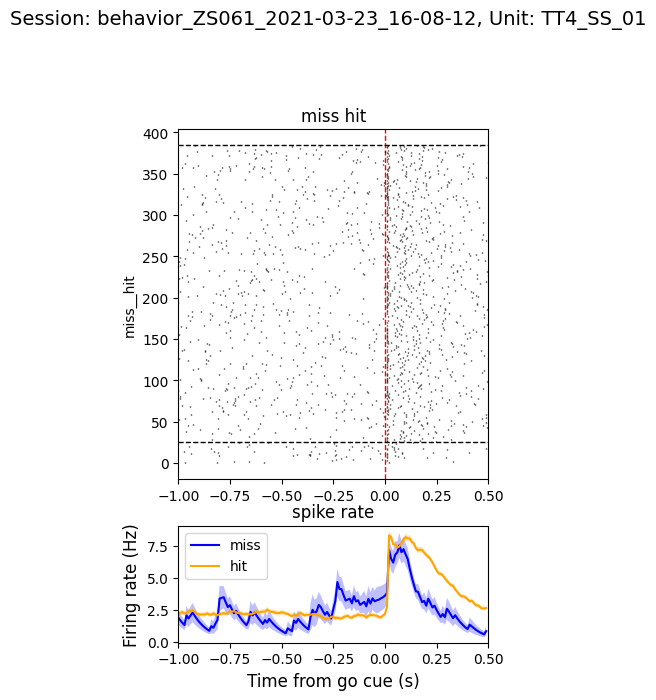

In [51]:
for curr_ind, curr_example in enumerate(examples):
    session = curr_example[0]
    unit_id = curr_example[1]
    session_df = get_session_tbl(session)
    unit_tbl = get_unit_tbl(session, data_type='curated')
    spike_times = unit_tbl.loc[unit_tbl['unit_id'] == unit_id, 'spike_times'].values[0] 
    unit_drift = load_drift(session, unit_id, data_type='curated')
    session_df_curr = session_df.copy()
    spike_times_curr = spike_times.copy()
    if unit_drift is not None:
        if unit_drift['ephys_cut'][0] is not None:
            spike_times_curr = spike_times_curr[spike_times_curr >= unit_drift['ephys_cut'][0]]
            session_df_curr = session_df_curr[session_df_curr['goCue_start_time'] >= unit_drift['ephys_cut'][0]]
        if unit_drift['ephys_cut'][1] is not None:
            spike_times_curr = spike_times_curr[spike_times_curr <= unit_drift['ephys_cut'][1]]
            session_df_curr = session_df_curr[session_df_curr['goCue_start_time'] <= unit_drift['ephys_cut'][1]]
    fig = plt.figure(figsize=(4,12))
    gs = gridspec.GridSpec(2, 1, height_ratios=[2, 1], hspace=0.4)
    fig, ax1, ax2 = plot_raster_rate(spike_times_curr,session_df_curr['goCue_start_time'].values, 
                                session_df_curr['animal_response'].values!=2, [-1, 0.5, 2], ['miss', 'hit'], 
                                custom_cmap, fig, gs[0], kernel = True, tb=-1, tf=0.5, tau_decay=0.08, tau_rise=0.001, step_size= 0.01)
    ax2.set_ylabel('Firing rate (Hz)', fontsize=12)
    ax2.set_xlabel('Time from go cue (s)', fontsize=12)
    plt.suptitle(f'Session: {session}, Unit: {unit_id}', fontsize=14)
    plt.tight_layout()
    plt.savefig(os.path.join(target_folder, f'hit-miss_{session}_{unit_id}.pdf'))
    plt.savefig(os.path.join(target_folder, f'hit-miss_{session}_{unit_id}.svg'))

# Example neurons for rpe

In [52]:
examples_rpe = [('behavior_ZS061_2021-03-23_16-08-12', 'TT3_SS_01', None),
                ('behavior_ZS061_2021-03-24_17-24-09', 'TT3_SS_01', None),
                ('behavior_ZS061_2021-03-25_17-12-27', 'TT3_SS_01', 'Figure6d_right'),
                ('behavior_ZS061_2021-03-26_17-28-33', 'TT1_SS_02', None),
                ('behavior_ZS061_2021-03-28_16-35-51', 'TT1_SS_03', None),
                ('behavior_ZS061_2021-03-28_16-35-51', 'TT3_SS_01', None),
                ('behavior_ZS061_2021-03-29_17-48-18', 'TT1_SS_03', 'Figure6d_left'),
                ('behavior_ZS061_2021-03-30_16-57-26', 'TT1_SS_01', None),
                ('behavior_ZS061_2021-03-31_17-15-48', 'TT1_SS_01', None),
                ('behavior_ZS061_2021-04-26_18-08-01', 'TT4_SS_01', None),
                ('behavior_ZS061_2021-04-28_16-35-50', 'TT4_SS_01', None),
                ('behavior_ZS061_2021-04-29_16-18-51', 'TT4_SS_01', None),
                ('behavior_ZS062_2021-05-07_17-38-21', 'TT6_SS_01', None),
                ('behavior_ZS062_2021-05-10_19-15-51', 'TT7_SS_01', None)]


In [53]:
custom_cmap = LinearSegmentedColormap.from_list('rpe', [(0.0, 'red'), (0.5, 'white'), (1.0, 'blue')])

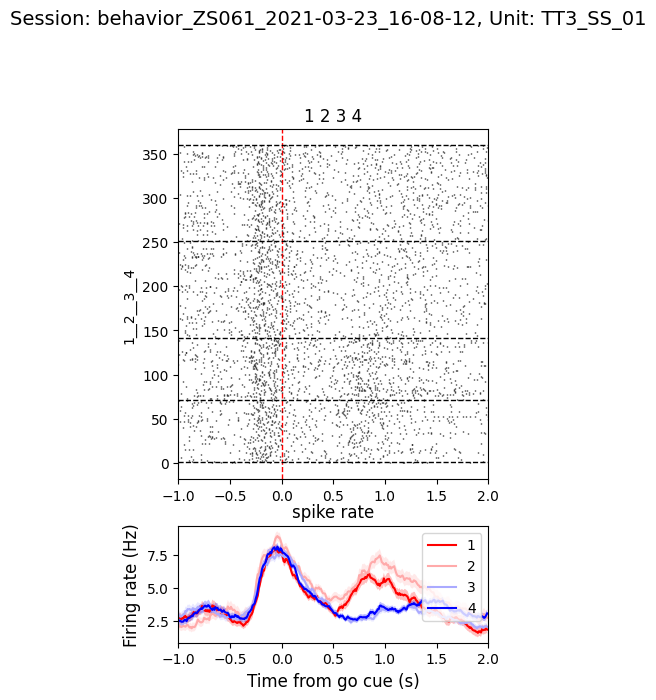

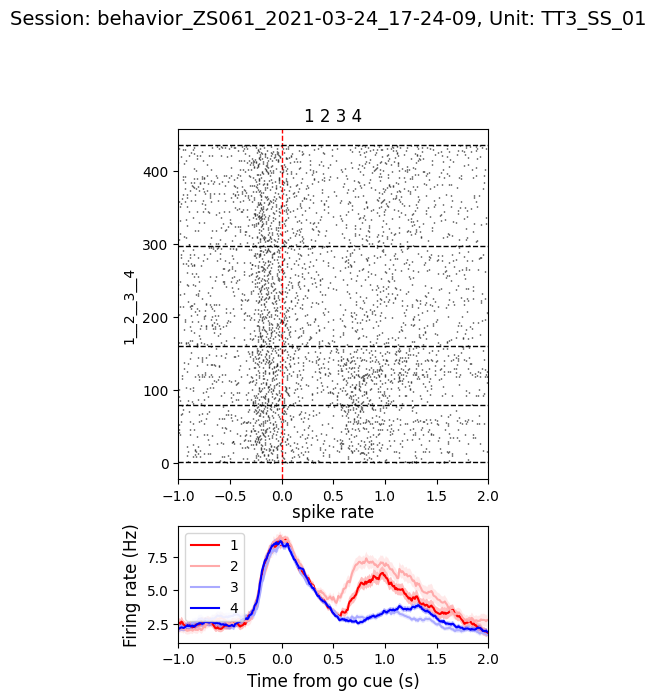

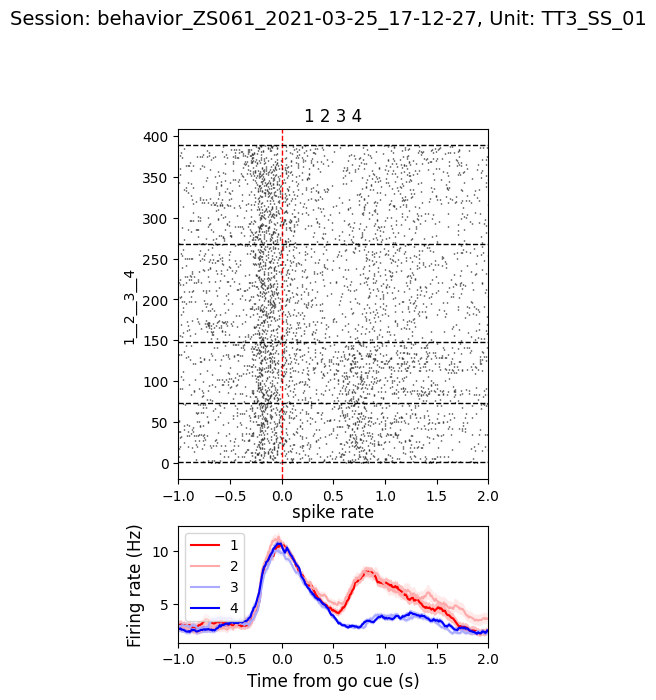

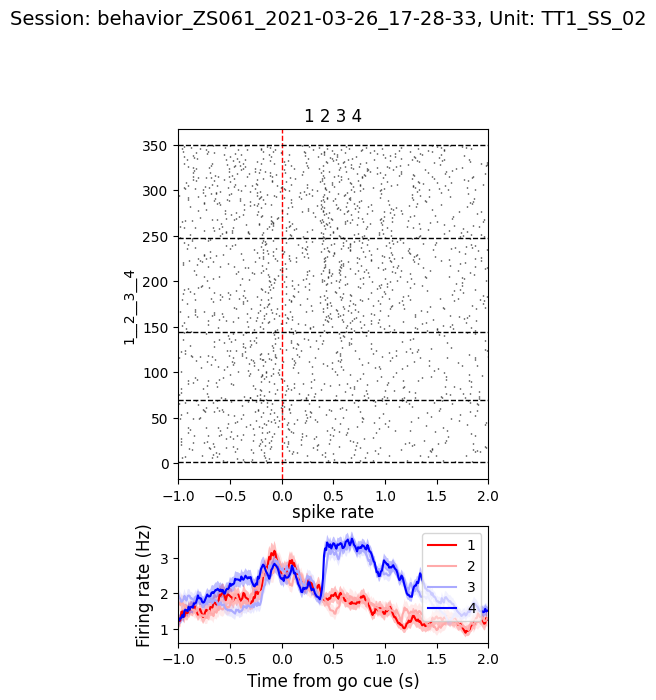

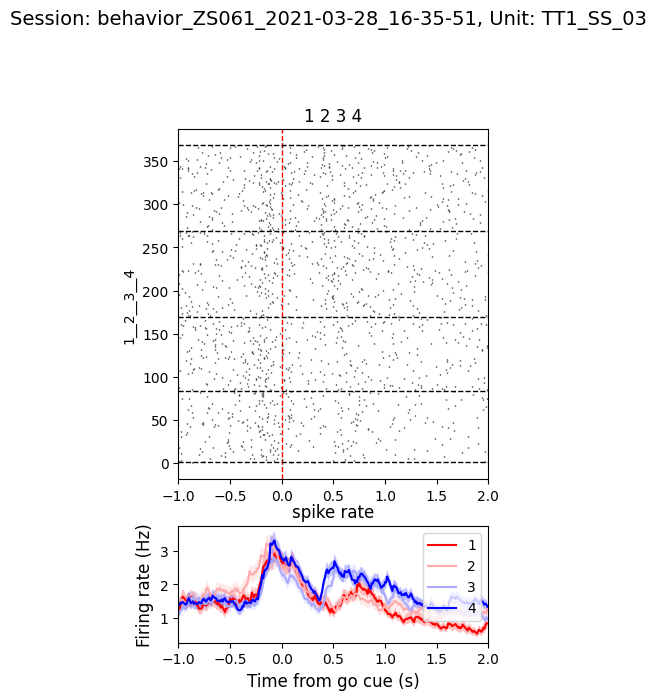

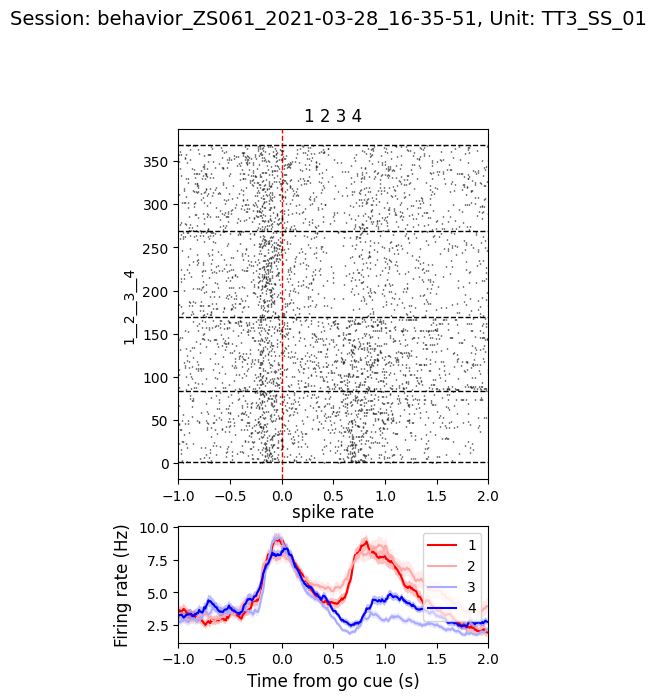

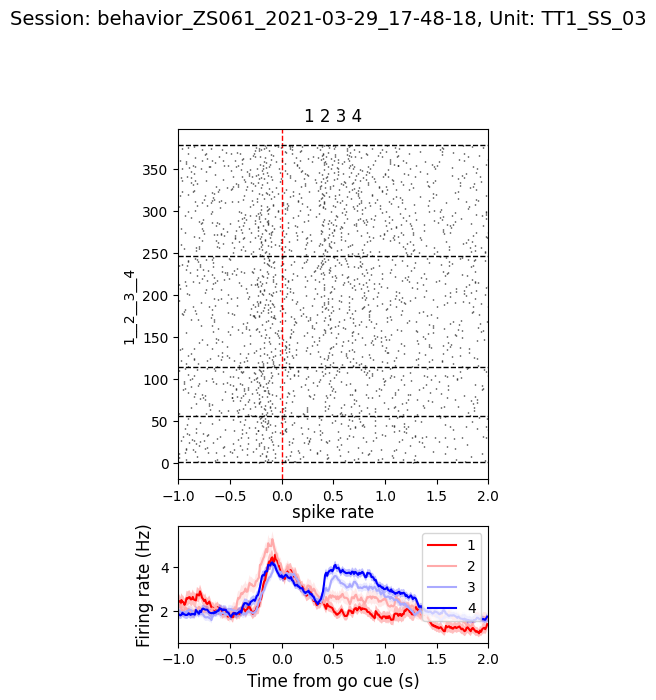

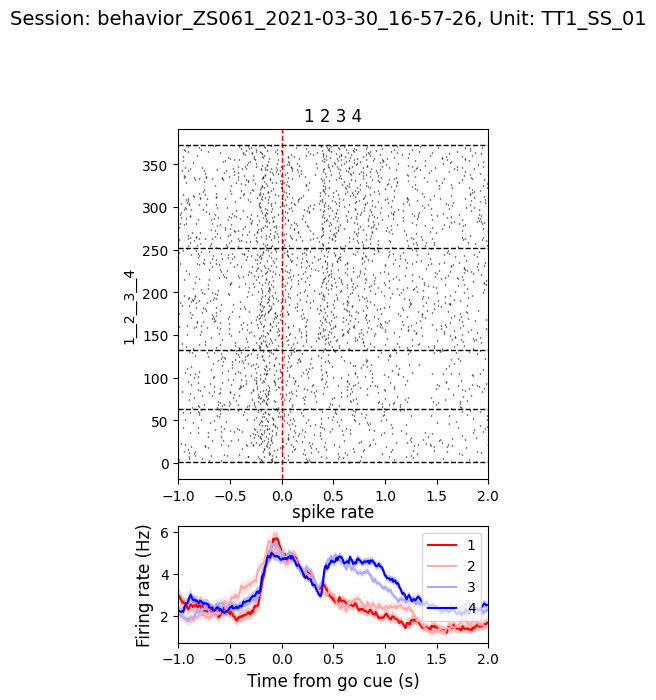

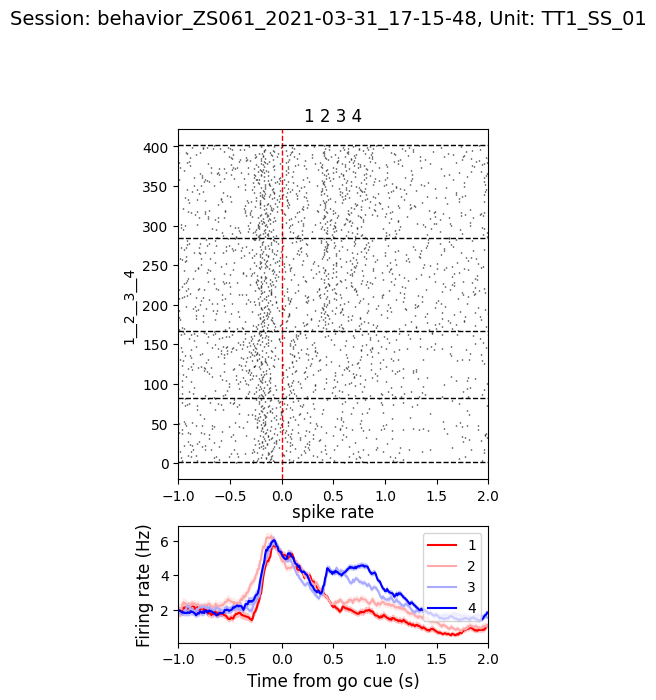

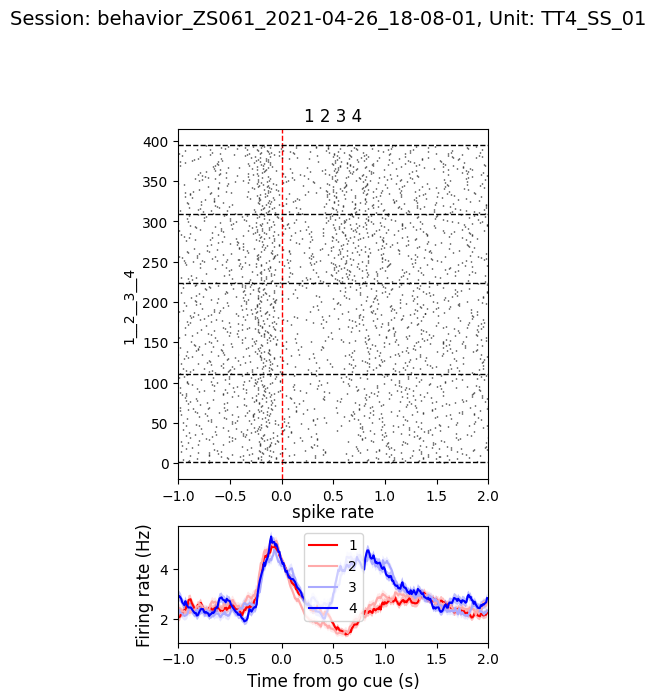

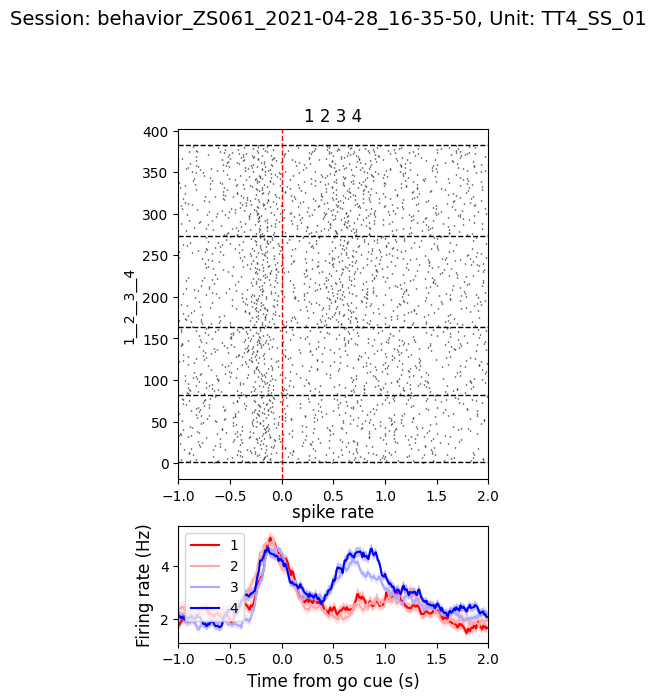

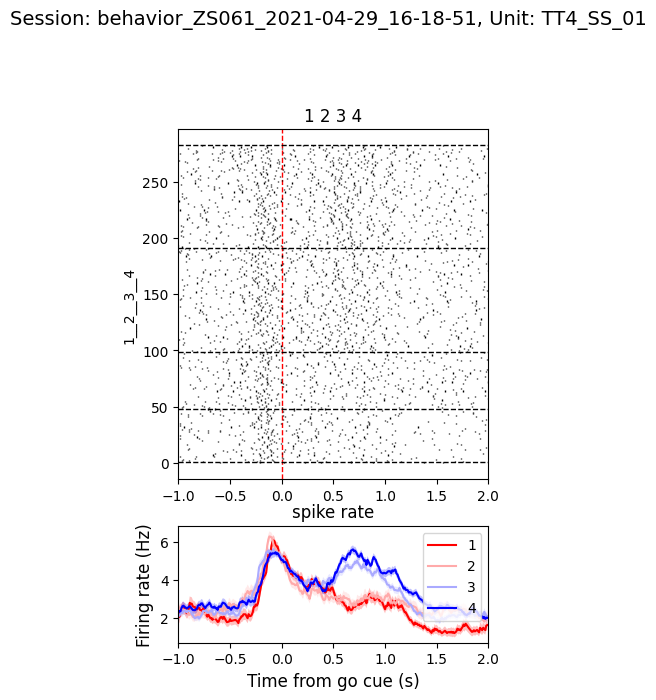

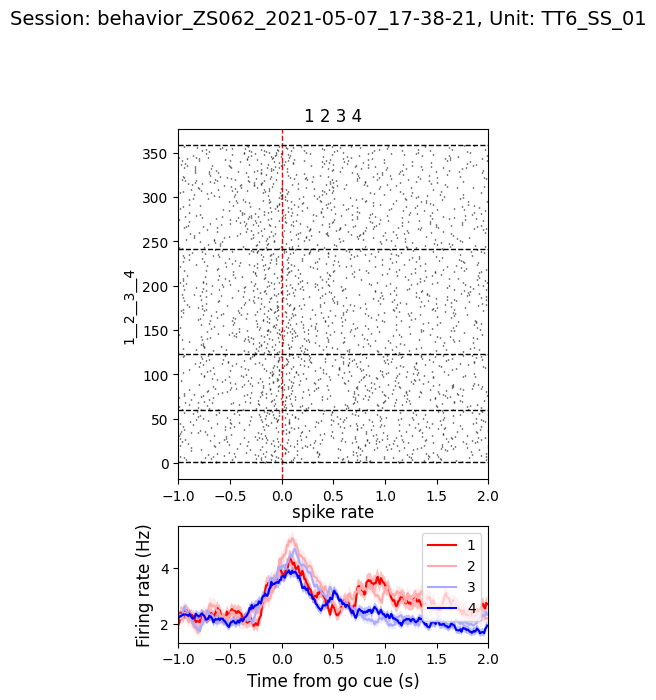

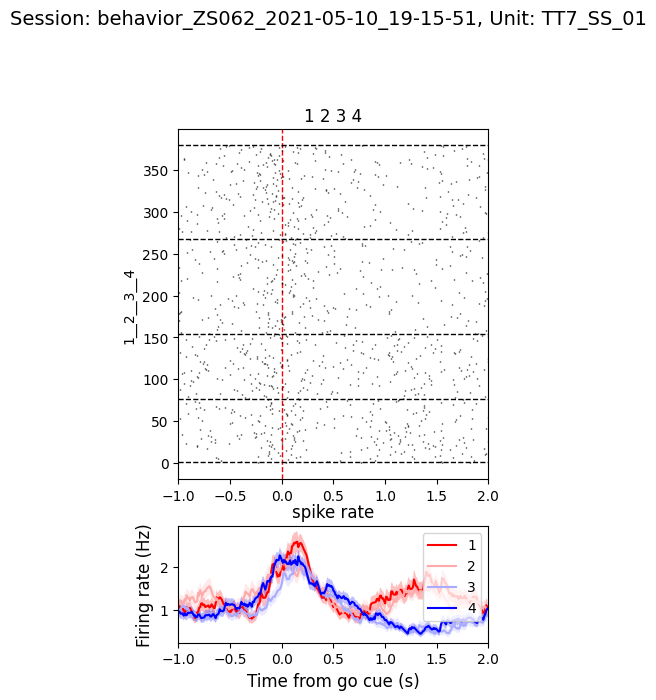

In [54]:
for curr_ind, curr_example in enumerate(examples_rpe):
    session = curr_example[0]
    unit_id = curr_example[1]
    save_fig = curr_example[2]
    session_df = makeSessionDF(session, model_name='stan_qLearning_5params')
    unit_tbl = get_unit_tbl(session, data_type='curated')
    spike_times = unit_tbl.loc[unit_tbl['unit_id'] == unit_id, 'spike_times'].values[0] 
    unit_drift = load_drift(session, unit_id, data_type='curated')
    session_df_curr = session_df.copy()
    spike_times_curr = spike_times.copy()
    # equal bins
    pe_bins = [-1.1, -0.5, 0, 0.5, 1.1]
    # non-equal bins
    target_vals = session_df_curr['pe'].values
    pe_bins_neg = np.quantile(target_vals[target_vals<0], [0, 0.5, 1])
    pe_bins_pos = np.quantile(target_vals[target_vals>0], [0, 0.5, 1])
    pe_bins = np.concatenate((pe_bins_neg[:-1], pe_bins_pos))
    
    if unit_drift is not None:
        if unit_drift['ephys_cut'][0] is not None:
            spike_times_curr = spike_times_curr[spike_times_curr >= unit_drift['ephys_cut'][0]]
            session_df_curr = session_df_curr[session_df_curr['goCue_start_time'] >= unit_drift['ephys_cut'][0]]
        if unit_drift['ephys_cut'][1] is not None:
            spike_times_curr = spike_times_curr[spike_times_curr <= unit_drift['ephys_cut'][1]]
            session_df_curr = session_df_curr[session_df_curr['goCue_start_time'] <= unit_drift['ephys_cut'][1]]
    fig = plt.figure(figsize=(4,12))
    gs = gridspec.GridSpec(2, 1, height_ratios=[2, 1], hspace=0.4)
    fig, ax1, ax2 = plot_raster_rate(spike_times_curr,session_df_curr['choice_time'].values, 
                                session_df_curr['pe'], pe_bins, ['1', '2', '3', '4'], 
                                custom_cmap, fig, gs[0], kernel = True, tb=-1, tf=2, tau_decay=0.2, tau_rise=0.001, step_size= 0.01)
    ax2.set_ylabel('Firing rate (Hz)', fontsize=12)
    ax2.set_xlabel('Time from go cue (s)', fontsize=12)
    plt.suptitle(f'Session: {session}, Unit: {unit_id}', fontsize=14)
    plt.tight_layout()
    plt.savefig(os.path.join(target_folder, f'rpe_{session}_{unit_id}.pdf'))
    plt.savefig(os.path.join(target_folder, f'rpe_{session}_{unit_id}.svg'))
    if save_fig is None:
        plt.savefig(os.path.join(target_folder, f'rpe_{session}_{unit_id}.pdf'))
        plt.savefig(os.path.join(target_folder, f'rpe_{session}_{unit_id}.svg'))     
    else:
        # save_panels(fig, save_dir, 'GLM_hit_reward_coefficients', ['Figure5a'], exts=('pdf',), bbox_inches='tight')
        save_panels(fig, target_folder, f'{session}_{unit_id}_rpe', [save_fig], exts=('pdf',), bbox_inches='tight')

        # Save raster data as CSV: one row per trial sorted by pe,
        # columns: pe, spike_0, spike_1, ... (relative times to choice_time)
        tb_raster, tf_raster = -1, 2
        alignment_times = session_df_curr['choice_time'].values
        pe_vals = session_df_curr['pe'].values
        sort_idx = np.argsort(pe_vals)
        rows = []
        for trial_idx in sort_idx:
            t0 = alignment_times[trial_idx]
            rel_spikes = spike_times_curr[(spike_times_curr >= t0 + tb_raster) & (spike_times_curr <= t0 + tf_raster)] - t0
            rows.append({'pe': pe_vals[trial_idx], 'spike_times': rel_spikes.tolist()})
        max_spikes = max(len(r['spike_times']) for r in rows) if rows else 0
        raster_records = []
        for r in rows:
            rec = {'pe': r['pe']}
            spikes = r['spike_times']
            for k in range(max_spikes):
                rec[f'spike_{k}'] = spikes[k] if k < len(spikes) else np.nan
            raster_records.append(rec)
        raster_df = pd.DataFrame(raster_records)
        raster_df.to_csv(os.path.join(target_folder, f'{save_fig}_rpe_{session}_{unit_id}_raster.csv'), index=False)


# Example session

In [55]:
session_id = 'behavior_ZS061_2021-04-08_18-01-30'
session_df = makeSessionDF(session_id, model_name='stan_qLearning_5params')

In [56]:
p_right = session_df['pChoice'].values
p_right[session_df['choice'].values == 0] = 1 - p_right[session_df['choice'].values == 0]
session_df['pRight'] = p_right

In [57]:
# 5-point moving average kernel
kernel = np.ones(5)
kernel = kernel / kernel.sum()

# Smooth choices
choices = session_df['choice'].values.copy()
choices[choices == 0] = -1  # Convert 0 to -1 for smoothing
smoothedChoice = np.convolve(choices, kernel, mode='full')
smoothedChoice = smoothedChoice[2:-2]   # MATLAB 3:end-2
smoothedChoice[:2] = np.nan
smoothedChoice[-2:] = np.nan

# Smooth rewards
rwds = session_df['outcome'].values.copy()
rwds = rwds * choices
smoothedRwd = np.convolve(rwds, kernel, mode='full')
smoothedRwd = smoothedRwd[2:-2]
smoothedRwd[:2] = np.nan
smoothedRwd[-2:] = np.nan

# block transitions

block_change_L = session_df['reward_probabilityL'].values[1:] != session_df['reward_probabilityL'].values[:-1]
block_change_L = np.where(block_change_L)[0] + 1  # Get indices of block changes
block_change_R = session_df['reward_probabilityR'].values[1:] != session_df['reward_probabilityR'].values[:-1]
block_change_R = np.where(block_change_R)[0] + 1  # Get indices of block changes

['/root/capsule/scratch/results/manuscript/figures/F_ephys_beh_action&outcome/example_figs/Figure4b_behavior_ZS061_2021-04-08_18-01-30_example_behavior.csv']

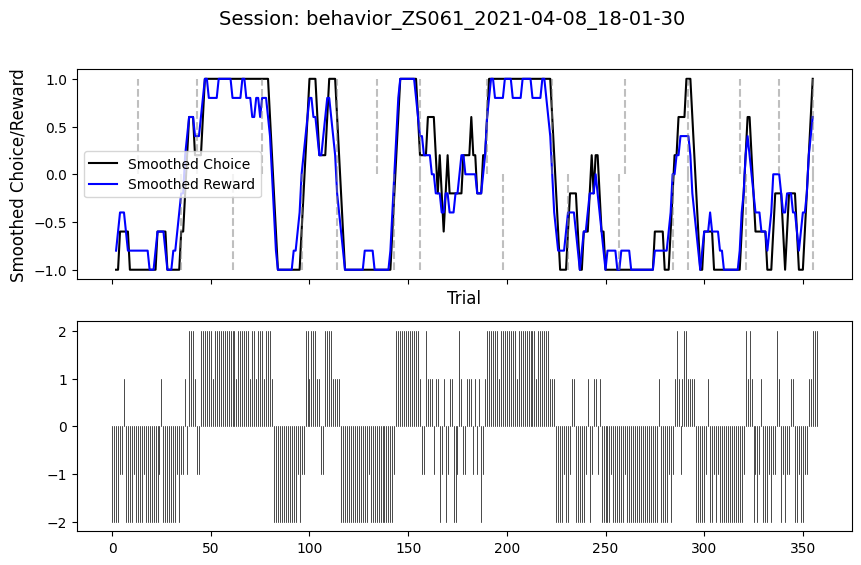

In [58]:
fig, ax = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
ax[0].plot(smoothedChoice, color='k')
ax[0].set_ylabel('Smoothed Choice/Reward', fontsize=12)
ax[0].plot(smoothedRwd, color='b')
ax[0].legend(['Smoothed Choice', 'Smoothed Reward'], fontsize=10)

# plot block transitions
for bc in block_change_L:
    ax[0].plot([bc, bc], [0, -1], color='gray', linestyle='--', alpha=0.5)
for bc in block_change_R:
    ax[0].plot([bc, bc], [0, 1], color='gray', linestyle='--', alpha=0.5)  
plt.suptitle(f'Session: {session_id}', fontsize=14)

for i in range(len(session_df)):
    ax[1].plot([i, i], [0, choices[i] + rwds[i]], color='k', alpha=1, linewidth=0.5)

ax[0].set_xlabel('Trial', fontsize=12)
##Figure4b##
save_panels(fig, target_folder, f'{session_id}_example_behavior', ['Figure4b'], exts=('pdf',), bbox_inches='tight')
save_panel_csv(session_df, target_folder, f'{session_id}_example_behavior', ['Figure4b'])

In [59]:
# 5-point moving average kernel
kernel = np.ones(5)
kernel = kernel / kernel.sum()

# Smooth choices
choices = session_df['choice'].values.copy()
smoothedChoice = np.convolve(choices, kernel, mode='full')
smoothedChoice = smoothedChoice[2:-2]   # MATLAB 3:end-2
smoothedChoice[:2] = np.nan
smoothedChoice[-2:] = np.nan


['/root/capsule/scratch/results/manuscript/figures/F_ephys_beh_action&outcome/example_figs/Figure6b_choices_vs_RLmodel.csv']

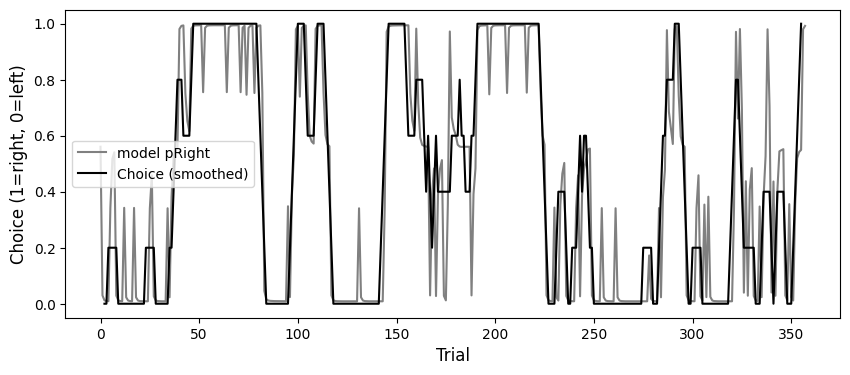

In [60]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(session_df['pRight'].values, color='gray', label='model pRight')
ax.plot(smoothedChoice, color='k', label='Choice (smoothed)')
ax.set_ylabel('Choice (1=right, 0=left)', fontsize=12)
ax.set_xlabel('Trial', fontsize=12)
ax.legend()
#Figure6b
save_panels(fig, target_folder, 'choice_model', ['Figure6b'], exts=('pdf',), bbox_inches='tight')
_c = {'model_predictedf_pRight': session_df['pRight'].values, 'smoothedChoice': smoothedChoice}
save_panel_csv(columns_to_df(**_c), target_folder, 'choices_vs_RLmodel', ['Figure6b'])

# Example tonic-phasic modulation

In [61]:
def plot_example_session_autoinhibition(session_id, unit_id, figure_panel):
    unit_tbl = get_unit_tbl(session_id, data_type='curated')
    spike_times = unit_tbl.loc[unit_tbl['unit_id'] == unit_id, 'spike_times'].values[0]
    session_tbl = get_session_tbl(session_id)
    unit_drift = load_drift(session, unit_id, data_type='curated')
    session_df_curr = session_tbl.copy()
    spike_times_curr = spike_times.copy()

    if unit_drift is not None:
        if unit_drift['ephys_cut'][0] is not None:
            spike_times_curr = spike_times_curr[spike_times_curr >= unit_drift['ephys_cut'][0]]
            session_df_curr = session_df_curr[session_df_curr['goCue_start_time'] >= unit_drift['ephys_cut'][0]]
        if unit_drift['ephys_cut'][1] is not None:
            spike_times_curr = spike_times_curr[spike_times_curr <= unit_drift['ephys_cut'][1]]
            session_df_curr = session_df_curr[session_df_curr['goCue_start_time'] <= unit_drift['ephys_cut'][1]]
    align_events = session_df_curr['goCue_start_time'].values
    tb = -0.1
    tf = 0.1
    df = align.to_events(spike_times_curr, align_events, (0, tf), return_df=True)
    # for each event, find the shortest time after alignment
    first_spike_after = df.groupby('event_index')['time'].min()
    # sort by the first spike time after alignment
    sorted_indices = first_spike_after.sort_values().index
    df = align.to_events(spike_times_curr, align_events[sorted_indices], (tb, tf), return_df=True)
    # reorder the DataFrame based on the sorted indices
    fig, ax1 = plt.subplots(figsize=(2, 4))
    # vertical line at time 0
    ax1.axvline(x=0, c="r", ls="--", lw=1, zorder=1)

    # raster plot
    N_lines = df['event_index'].max() + 1

    # full bar height in y-units
    bar_height =1

    y0 = df.event_index - bar_height / 2
    y1 = df.event_index + bar_height / 2

    ax1.vlines(df.time, y0, y1, color="k", linewidth=1)

    ax1.set_xlim(tb, tf)
    ax1.set_xlabel('Time from go cue (s)', fontsize=12)
    ax1.set_ylabel('Trials sorted by first spike', fontsize=12)
    ax1.set_ylim(-1, N_lines)
    ax1.set_title(f'Session: {session_id}, Unit: {unit_id}', fontsize=12)
    plt.tight_layout()
    ##Figure4f##
    save_panels(fig, target_folder, f'{session_id}_{unit_id}_first_spike_sorted', [figure_panel], exts=('pdf',), bbox_inches='tight')

    # Save raster data as CSV: one row per trial sorted by first spike time,
    # columns: first_spike_time, spike_0, spike_1, ... (relative to alignment)
    raster_records = []
    for trial_rank, orig_trial_idx in enumerate(sorted_indices):
        t0 = align_events[orig_trial_idx]
        rel_spikes = spike_times_curr[(spike_times_curr >= t0 + tb) & (spike_times_curr <= t0 + tf)] - t0
        first_spike = first_spike_after.get(orig_trial_idx, np.nan)
        rec = {'first_spike_time': first_spike}
        for k, s in enumerate(rel_spikes):
            rec[f'spike_{k}'] = s
        raster_records.append(rec)
    max_spikes = max((sum(1 for k in r if k.startswith('spike_')) for r in raster_records), default=0)
    for rec in raster_records:
        for k in range(max_spikes):
            rec.setdefault(f'spike_{k}', np.nan)
    raster_df = pd.DataFrame(raster_records)
    raster_df.to_csv(os.path.join(target_folder, f'{figure_panel}_{session_id}_{unit_id}_raster.csv'), index=False)


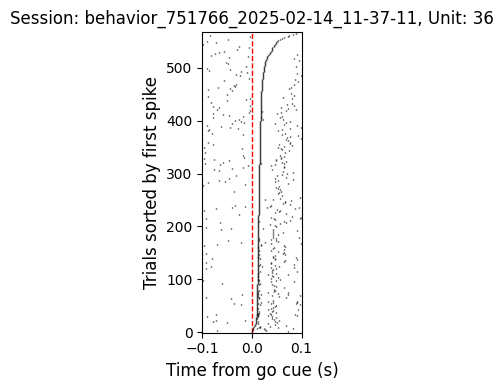

In [62]:
plot_example_session_autoinhibition('behavior_751766_2025-02-14_11-37-11', 36, 'Figure4f')

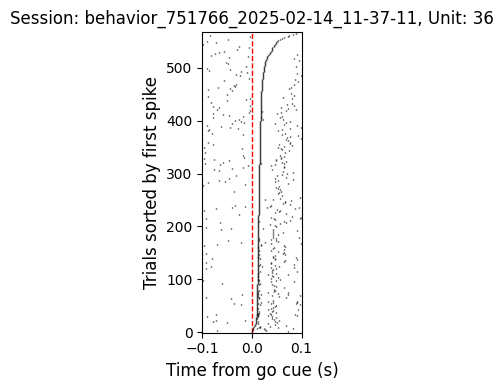

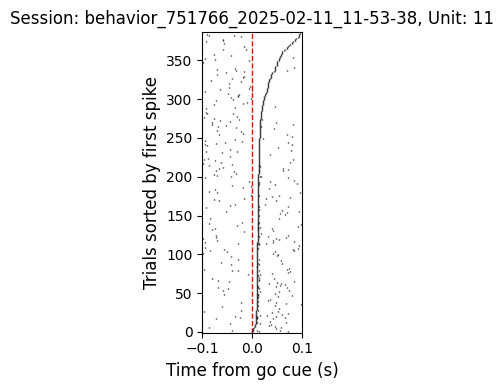

In [63]:
plot_example_session_autoinhibition('behavior_751766_2025-02-14_11-37-11', 36, 'FigureS15d_left')
plot_example_session_autoinhibition('behavior_751766_2025-02-11_11-53-38', 11, 'FigureS15d_right')

In [64]:
plot_example_session_autoinhibition('behavior_751766_2025-02-14_11-37-11', 11, 'FigureS15d_left')

IndexError: index 0 is out of bounds for axis 0 with size 0

# Antidromic cell

In [ ]:
session = 'behavior_752014_2025-03-26_11-18-57'
unit_id = 46

Plotting opto responses for unit 46
Number of opto units: 1


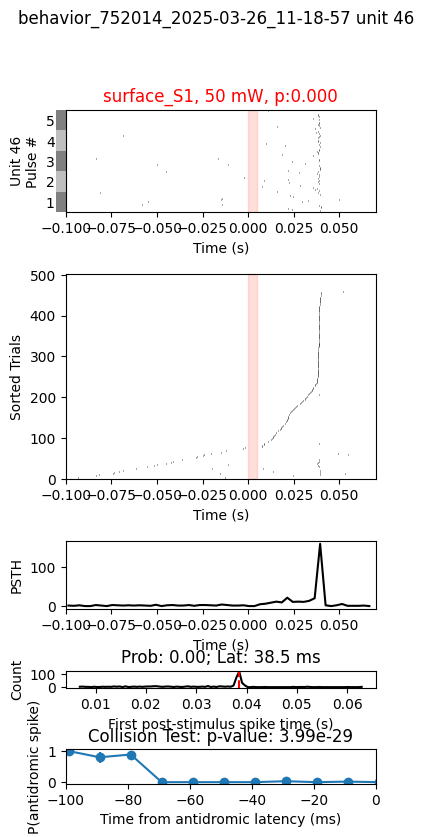

In [ ]:
from ani_session_processing.antidromic_analysis_session import remove_spikes_during_laser_pulse
import utils.analysis_funcs as af
import utils.plotting_funcs as pf

data_type = 'curated'
session_dir = session_dirs(session)
unit_tbl = get_unit_tbl(session, data_type=data_type)
unit_tbl = unit_tbl[unit_tbl['unit_id']==unit_id]
opto_csv_file = os.path.join(session_dir[f'opto_dir_{data_type}'], f'{session}_opto_session.csv')
if os.path.exists(opto_csv_file):
    event_ids = pd.read_csv(opto_csv_file)
event_ids = event_ids[event_ids['emission_location'] == 'surface_S1']
for i in range(len(unit_tbl)):
    unit_df = unit_tbl.iloc[[i]]   # double brackets → keeps it as a DataFrame
    unit_id = unit_tbl['unit_id'].values[i]
    print(f'Plotting opto responses for unit {unit_id}')
    unit_drift = load_drift(session, unit_id, data_type=data_type)
    event_ids_curr = event_ids.copy()
    
    if unit_drift is not None:
        if unit_drift['ephys_cut'][0] is not None:
            event_ids_curr = event_ids_curr[event_ids_curr['time']>=unit_drift['ephys_cut'][0]]
        if unit_drift['ephys_cut'][1] is not None:
            event_ids_curr = event_ids_curr[event_ids_curr['time']<=unit_drift['ephys_cut'][1]]
    if len(event_ids_curr) > 0:  
        fig = plot_opto_responses(unit_df, event_ids_curr)
        fig.suptitle(f'{session} unit {unit_tbl["unit_id"].values[i]}')
        ##FigureS13j##
        save_panels(fig, target_folder, f'{session}_{unit_id}_opto', ['FigureS13j'], exts=('pdf',), bbox_inches='tight')

        # Recompute trial data for CSV export (mirrors plot_opto_responses internals)
        unit_spike_times = unit_df['spike_times'].values[0]
        prepost = 'post'
        tag_trials = event_ids_curr[event_ids_curr['pre_post'] == prepost] if 'pre_post' in event_ids_curr.columns else event_ids_curr
        if tag_trials.empty:
            prepost = 'pre'
            tag_trials = event_ids_curr.copy()
        max_power = tag_trials['power'].max()
        tag_trials = tag_trials[tag_trials['power'] == max_power]
        duration = np.unique(tag_trials['duration'])[0]
        num_pulses = int(np.unique(tag_trials['num_pulses'])[0])
        pulse_interval = np.unique(tag_trials['pulse_interval'])[0]
        time_range_raster = np.array([-100 / 1000, 70 / 1000])
        this_event_timestamps = tag_trials['time'].tolist()
        int_event_locked_timestamps = []
        pulse_nums = []
        for pulse_num in range(num_pulses):
            time_shift = pulse_num * (duration + pulse_interval) / 1000
            this_time_range = time_range_raster + time_shift
            this_locked = af.event_locked_timestamps(
                unit_spike_times, this_event_timestamps, this_time_range, time_shift=time_shift
            )
            int_event_locked_timestamps.extend(this_locked)
            pulse_nums.extend([pulse_num + 1] * len(this_locked))
        int_event_locked_timestamps = remove_spikes_during_laser_pulse(int_event_locked_timestamps, duration)

        # Raster CSV: one row per trial, columns: trial, pulse_num, spike_0, spike_1, ...
        raster_records = []
        for trial_i, spikes in enumerate(int_event_locked_timestamps):
            rec = {'trial': trial_i, 'pulse_num': pulse_nums[trial_i]}
            for k, s in enumerate(spikes):
                rec[f'spike_{k}'] = s
            raster_records.append(rec)
        max_spikes = max((sum(1 for k in r if k.startswith('spike_')) for r in raster_records), default=0)
        for rec in raster_records:
            for k in range(max_spikes):
                rec.setdefault(f'spike_{k}', np.nan)
        raster_df = pd.DataFrame(raster_records)
        save_panel_csv(raster_df, target_folder, f'{session}_{unit_id}_opto', ['FigureS13j'], plot_type='raster')

        # Mean FR CSV: time_bin, mean_fr
        psth, _, bins = pf.psth(int_event_locked_timestamps, time_range_raster, bin_size=0.003, smooth_window_size=3)
        save_panel_csv(columns_to_df(time_bin=bins, mean_fr=psth), target_folder, f'{session}_{unit_id}_opto', ['FigureS13j'], plot_type='mean_fr')
